# 0. Imports

In [2]:
%cd ../../..

/workspace/sprite-flow


In [5]:
import torch

from sampling.conditional_probability_path import GaussianConditionalProbabilityPath
from sampling.sampleable import PixelArtSampler
from sampling.noise_scheduling import LinearAlpha, LinearBeta
from models.unet import PixelArtUNet
from training.trainer import UnguidedTrainer
from training.evaluation import FID
from training.ema import EMA
from diff_eq.ode_sde import UnguidedVectorFieldODE
from diff_eq.simulator import EulerSimulator
from utils.visualization import visualize_training_logs, plot_generated_images
from utils.helpers import clear_cuda, tensor_to_rgba_image, rgba_to_rgb, save_generated_assets, normalize_to_unit,  load_checkpoint


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Train

In [6]:
clear_cuda()

# Initialize probability path
sampler = PixelArtSampler('dataset/images').to(device)
path = GaussianConditionalProbabilityPath(
    p_data=sampler,
    p_simple_shape = [4, 128, 128],
    alpha = LinearAlpha(),
    beta = LinearBeta()
).to(device)

# Initialize model
unet = PixelArtUNet(
    channels = [128, 256, 512, 1024],
    num_residual_layers = 2,
    t_embed_dim = 128,
    midcoder_dropout_p=0.2
)

ema = EMA(model=unet, device=device, max_decay=0.9996, warmup_steps=2000)

# Initialize evaluation metric
metric = FID(
    feature=2048,
    image_size=(299, 299)
)

# Initialize trainer
trainer = UnguidedTrainer(
    path=path,
    model=unet,
    experiment_dir="training/experiments/unet_v3",
    eval_metric=metric,
    ema=ema,
)

# Train :D
trainer.train(
    device=device,
    num_epochs=20000,
    batch_size=64,
    lr=1e-4,
    lr_warmup_steps_frac=0.1,
    weight_decay=5e-4,
    resume=False,
    val_batch_size=256,
    num_val_batches=2,
    validate_every=500,
    val_timesteps=100,
    num_images_to_save=5,
    save_images_every=500,
)

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100.0%


Model size: 289.6665 MiB


 72%|███████▏  | 14372/20000 [6:30:13<1:43:12,  1.10s/it, train_loss=0.0490, val_metric=95.4, best_val_metric=95.4077 (epoch 13999)]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

 92%|█████████▏| 18499/20000 [8:18:46<28:23,  1.14s/it, train_loss=0.0444, val_metric=92.3, best_val_metric=89.0081 (epoch 15499)]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



# 2. Visualize model performance over time

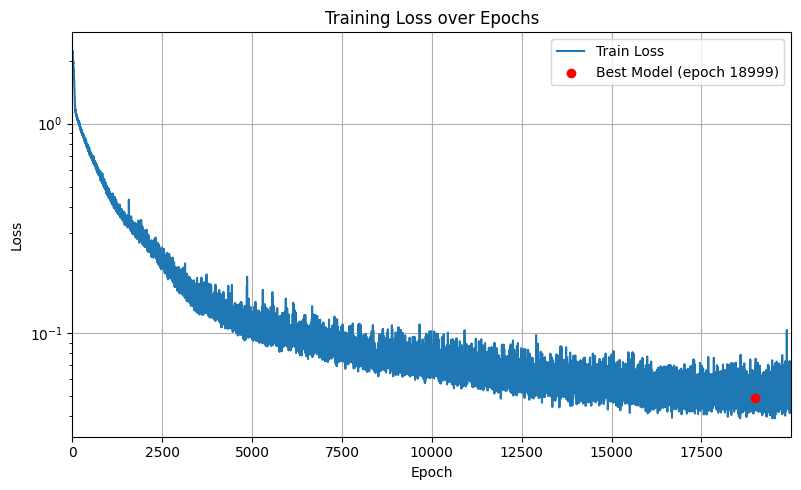

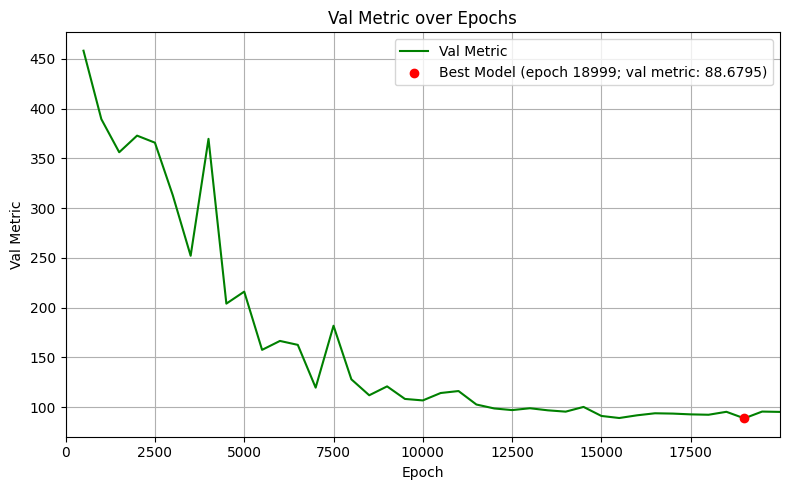

In [7]:
visualize_training_logs(log_path="training/experiments/unet_v3/training_log.csv", loss_scale='log')

# 3. Visualize results

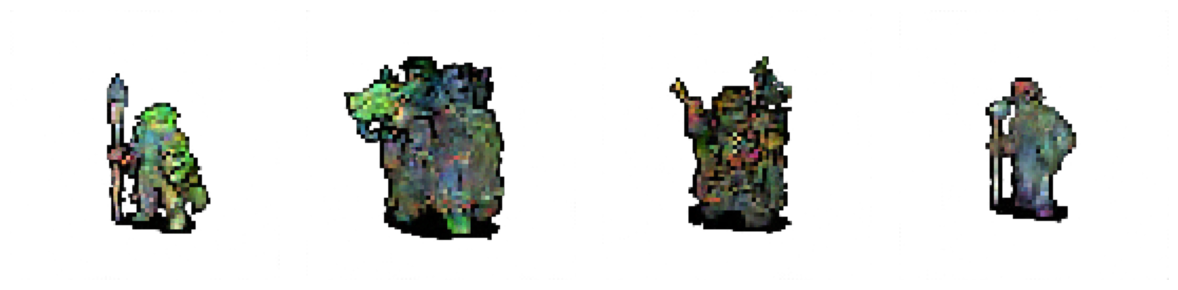

In [27]:
num_samples = 4
num_timesteps = 150

# Setup model
model = PixelArtUNet(
    channels = [128, 256, 512, 1024],
    num_residual_layers = 2,
    t_embed_dim = 128,
    midcoder_dropout_p=0.2
).to(device)

# Setup path
sampler = PixelArtSampler('dataset/images').to(device)
path = GaussianConditionalProbabilityPath(
    p_data=sampler,
    p_simple_shape=[4, 128, 128],
    alpha=LinearAlpha(),
    beta=LinearBeta()
).to(device)

# Setup EMA
ema = EMA(model, device=device)

load_checkpoint(model=model, device=device, filepath="training/experiments/unet_v3/best_model.pt", ema=ema)

# Prepare for inference
ema.apply_shadow()
path.eval()
model.eval()

# --- Simulate ---
ts = torch.linspace(0, 1, num_timesteps).view(1, -1, 1, 1, 1).expand(num_samples, -1, 1, 1, 1).to(device)
x0 = path.p_simple.sample(num_samples).to(device)  # (num_samples, 4, 128, 128)
ode = UnguidedVectorFieldODE(model)
simulator = EulerSimulator(ode)
x1 = simulator.simulate(x0, ts)  # (num_samples, 4, 128, 128)

x1 = normalize_to_unit(x1) # [-1, 1] -> [0, 1]

# Save to assets
imgs = tensor_to_rgba_image(x1)
save_generated_assets(images=imgs, num_timesteps=num_timesteps, path='assets/unet_v3')

# Convert to RGB
x1_rgb = rgba_to_rgb(x1)
imgs_rgb = tensor_to_rgba_image(x1_rgb)
plot_generated_images(imgs)

# 4. Evaluate on the test set

In [19]:
# Setup model
model = PixelArtUNet(
    channels = [128, 256, 512, 1024],
    num_residual_layers = 2,
    t_embed_dim = 128,
    midcoder_dropout_p=0.2
).to(device)

# Setup path
sampler = PixelArtSampler('dataset/images').to(device)
path = GaussianConditionalProbabilityPath(
    p_data=sampler,
    p_simple_shape=[4, 128, 128],
    alpha=LinearAlpha(),
    beta=LinearBeta()
).to(device)

# Setup EMA
ema = EMA(model, device=device)

load_checkpoint(model=model, device=device, filepath="training/experiments/unet_v3/best_model.pt", ema=ema)

# Prepare for evaluation
ema.apply_shadow()
path.eval()
model.eval()

# Evaluation metric
metric = FID(
    feature=2048,
    image_size=(299, 299)
)

# Trainer
trainer = UnguidedTrainer(
    path=path,
    model=model,
    experiment_dir="training/experiments/unet_v3",
    eval_metric=metric,
    ema=ema
)

# Evaluate on test set
test_fid = trainer.evaluate(
    batch_size=128,
    device=device,
    num_timesteps=100,
    mode="test"
)

print(f"FID on the test set (100 timesteps): {test_fid:.4f}")

FID on the test set (100 timesteps): 80.4755
